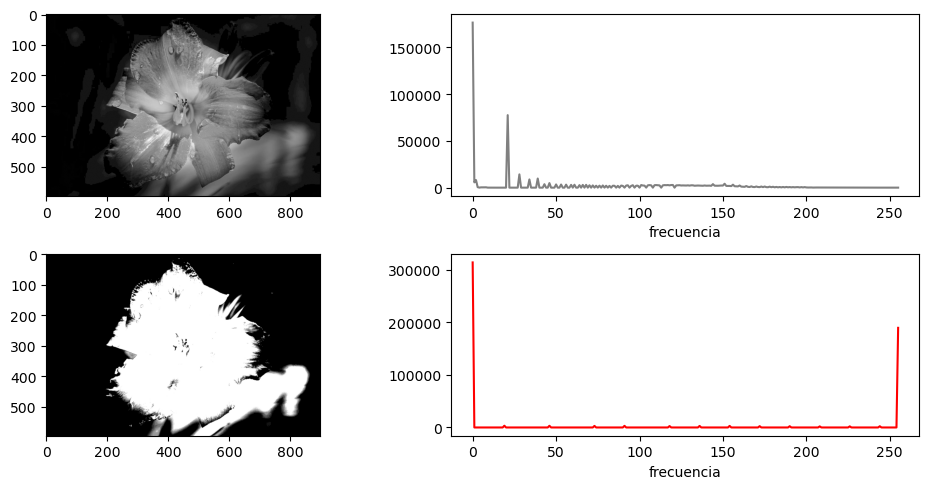

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def contraste(img,factor=1.0):
    img=img.astype(np.float32)
    media=np.mean(img)
    img_contraste=media+(img-media)*factor
    img_contraste=np.clip(img_contraste,0,255).astype(np.uint8)
    return img_contraste
img=cv2.imread('pego.png',0)
contrast=9
img_fin=contraste(img,contrast)
historgrama_ori=cv2.calcHist([img],[0],None,[256],[0,256])
histograma_new=cv2.calcHist([img_fin],[0],None,[256],[0,256])
###########
plt.figure(figsize=(10,5))
plt.subplot(221)
plt.imshow(img,cmap='gray')
plt.subplot(222)
plt.plot(historgrama_ori,color='gray')
plt.xlabel('intensidad')
plt.xlabel('frecuencia')
plt.subplot(223)
plt.imshow(img_fin,cmap='gray')
plt.subplot(224)
plt.plot(histograma_new,color='red')
plt.xlabel('intensidad')
plt.xlabel('frecuencia')
plt.tight_layout()

Calcular el histograma de un punto de interes a colores

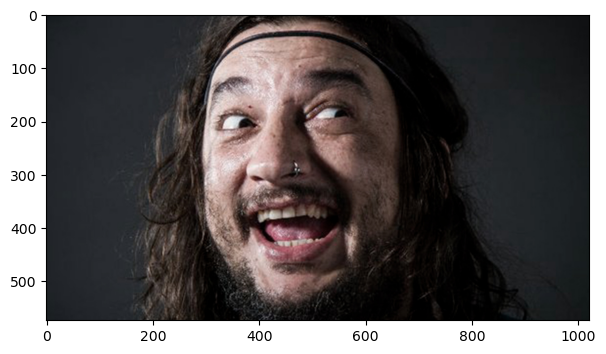

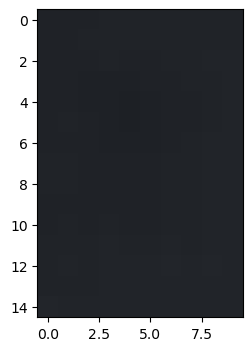

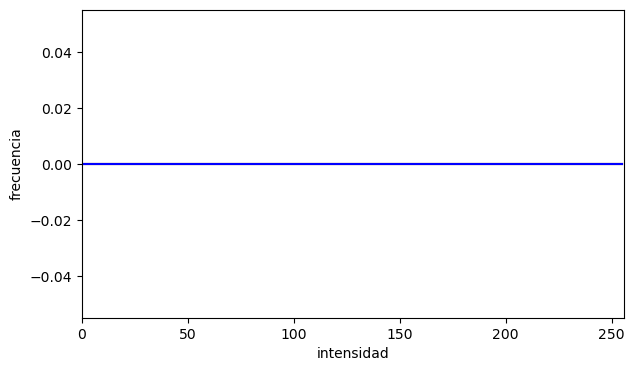

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imge = cv2.imread('bananero.jpg')
img_rgb = cv2.cvtColor(imge, cv2.COLOR_BGR2RGB)

plt.rcParams['figure.figsize'] = [7, 4]
plt.imshow(img_rgb)
plt.show()

plt.imshow(img_rgb[50:65, 20:30, :])
plt.show()

img_cortada = img_rgb[50:65, 20:30, :]
plt.imsave('img_recortada.jpg', img_cortada)

img_fin = plt.imread('img_recortada.jpg')
color = ('r', 'g', 'b')

for canal, col in enumerate(color):
    histograma = cv2.calcHist([img_fin.astype('float32') * 255], [canal], None, [256], [0, 256])
    plt.plot(histograma, color=col)
    plt.xlabel('intensidad')
    plt.ylabel('frecuencia')
    plt.xlim([0, 256])

plt.show()

ECUALIZACION DE UN HISTOGRAMA "SE DESEA NORMALIZAR UNA IMAGEN A UN PUNTO OPTIMO POR HISTOGRAMA"

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_8756\4264191244.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(),256,[0,256],color='r')


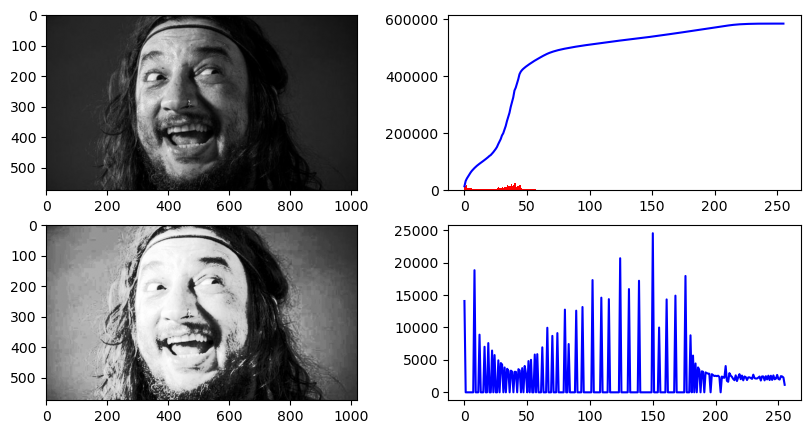

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('bananero.jpg',0)
histograma,calc=np.histogram(img.flatten(),256,[0,256])
distAcum=histograma.cumsum()
dist_norm=distAcum*histograma.max()/distAcum.max()
ecualizar=cv2.equalizeHist(img)
histograma_equ,_=np.histogram(ecualizar.flatten(),256,[0,256])

plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.imshow(img,cmap='gray')

plt.subplot(2,2,2)
plt.plot(distAcum,color='b')
plt.hist(img.flatten(),256,[0,256],color='r')

plt.subplot(2,2,3)
plt.imshow(ecualizar,cmap='gray')

plt.subplot(2,2,4)
plt.plot(histograma_equ,color='b')

plt.show()

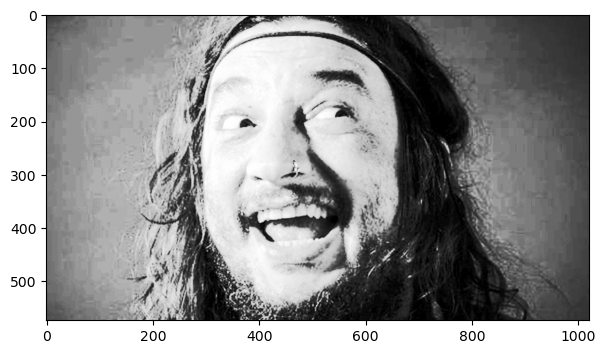

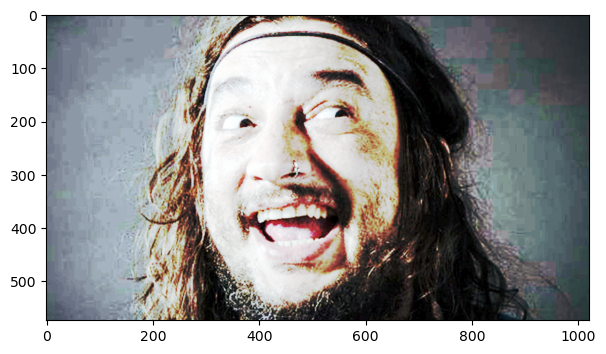

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('bananero.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ecualizada=cv2.equalizeHist(gray)
ecu_color=cv2.merge([
    cv2.equalizeHist(img[:,:,0]),
    cv2.equalizeHist(img[:,:,1]),
    cv2.equalizeHist(img[:,:,2])
])

plt.imshow(ecualizada,cmap='gray')
plt.show()

plt.imshow(cv2.cvtColor(ecu_color,cv2.COLOR_BGR2RGB))
plt.show()

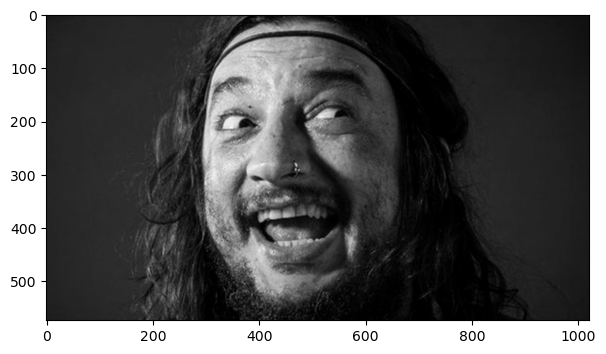

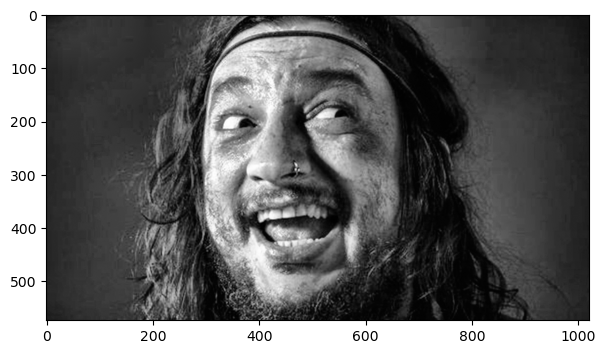

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('bananero.jpg',0)
clip=2.0
tiles=8
clahe=cv2.createCLAHE(clipLimit=clip,tileGridSize=(tiles,tiles))
ecualizado=clahe.apply(img)
plt.imshow(img,cmap='gray')
plt.show()
plt.imshow(ecualizado,cmap='gray')
plt.show()

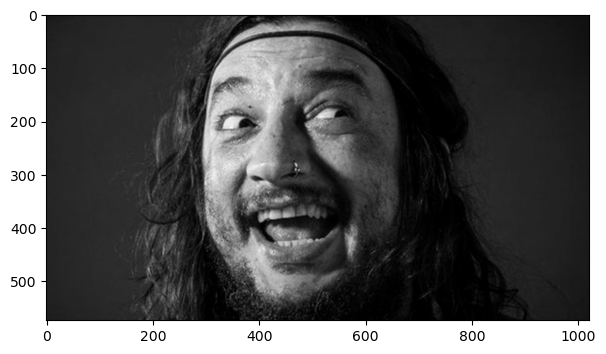

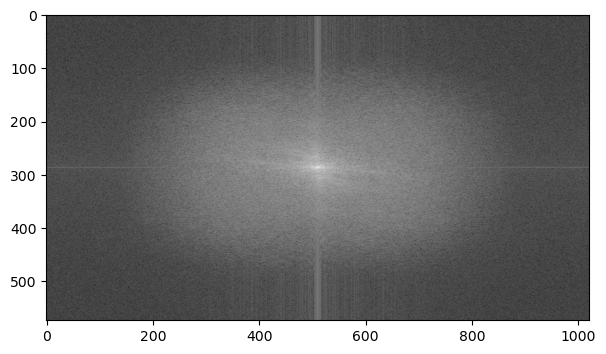

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('bananero.jpg',0)
transformada=np.fft.fft2(img)
desplazamiento=np.fft.fftshift(transformada)
magnitud_espectro=np.log(1+np.abs(desplazamiento))
plt.imshow(img,cmap='gray')
plt.show()
plt.imshow(magnitud_espectro,cmap='gray')
plt.show()